# Makine Öğrenmesi Final Projesi: Kan Hücresi Anomali Tespiti

**Proje Amacı:** Bu proje, kan hücrelerinden elde edilen sayısal ölçümleri ve kategorik verileri kullanarak hücresel anomalileri (hastalıkları veya anormal morfolojik durumları) makine öğrenmesi yaklaşımlarıyla tespit etmeyi amaçlamaktadır. Tıbbi teşhis süreçlerine karar destek mekanizması sunmak hedeflenmiştir.


# BÖLÜM 1 — Veri Ön İşleme (Preprocessing)

Bu bölüm, kan hücresi anomali tespit projesinde kullanılan ham verinin **modele hazır hale getirilmesi** sürecini adım adım belgelemektedir. Ön işleme süreci, makine öğrenmesi projelerinin en kritik aşamalarından birini oluşturur; zira modelin tahmin performansı doğrudan giriş verisinin kalitesine bağlıdır.

Aşağıdaki adımlar, endüstri standartları ve veri bilimi en iyi pratiklerine uygun olarak yapılandırılmıştır:

1. **Veriyi Yükleme ve İlk İnceleme**
2. **Veri Kalitesi Kontrolü**
3. **Veri Sızıntısı (Data Leakage) Sütunlarını Çıkarma**
4. **Eksik Veri Yönetimi (Imputation)**
5. **Kategorik Kodlama ve Veri Bölme**
6. **Özellik Ölçeklendirme (RobustScaler)**


In [22]:
import os
import warnings
import numpy as np # Matris ve matematiksel işlemler
import pandas as pd # Tablolar (DataFrame) ve veri manipülasyonu
import matplotlib.pyplot as plt # Temel çizimler
import seaborn as sns # İstatistiksel veri görselleştirme
import shap # Model kararlarını yorumlama (Explainable AI)

# Model doğrulama ve veri parçalama araçları
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# Aykırı değerlere dirençli ölçekleme ve etiket dönüştürme
from sklearn.preprocessing import RobustScaler, LabelEncoder
# Eksik değerleri doldurma
from sklearn.impute import SimpleImputer

# Sınıflandırma başarı metrikleri
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    average_precision_score,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
)

# Temel ve modern ağaç tabanlı modeller
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore") # Çıktıyı kirleten uyarıları kapat
sns.set_theme(style="darkgrid") # Grafikler için standart tema

# ── Sabitler ve Yapılandırma ──
DATA_DIR = "archive"
FILENAME = "blood_cell_anomaly_detection.csv"
TARGET = "anomaly_label" # Hedef değişken

# Veri sızıntısını (Data Leakage) önlemek için model eğitiminden çıkarılacak sütunlar
LEAKAGE_COLS = [
    "disease_category", "cell_type",
    "cytodiffusion_anomaly_score",
    "cytodiffusion_classification_confidence",
    "labeller_confidence_score",
]

ID_COLS = ["cell_id"] # Sadece tanımlayıcı, eğitimde yeri yok
MODEL_NAMES = ["XGBoost", "LightGBM", "Random Forest"]

from IPython.display import display
from sklearn.metrics import precision_recall_curve

print("✅ Kütüphaneler ve sabitler başarıyla yüklendi.")

✅ Kütüphaneler ve sabitler başarıyla yüklendi.


## Adım 1 — Veriyi Yükleme ve İlk İnceleme

İlk adımda, `pd.read_csv()` fonksiyonu ile ham veri seti disk üzerindeki CSV dosyasından belleğe yüklenir. Ardından verinin **boyutu** (`shape`) ve **ilk 5 satırı** (`head()`) yazdırılarak verinin yapısı hakkında ön bilgi edinilir.

Bu adım, veri setinin boyutunu, sütun isimlerini ve veri tiplerini anlamak açısından **keşifsel veri analizinin** (Exploratory Data Analysis, EDA) başlangıç noktasını oluşturur.


In [4]:
# Dosya yolunu birleştirip veriyi DataFrame olarak içeri alıyoruz
raw_df = pd.read_csv(os.path.join(DATA_DIR, FILENAME))

# Veri setinin hacmini (kaç satır, kaç sütun) hızlıca kontrol ediyoruz
print(f"📊 Veri Boyutu (Satır × Sütun): {raw_df.shape}")
print(f"   ➤ Toplam Gözlem Sayısı : {raw_df.shape[0]}")
print(f"   ➤ Toplam Özellik Sayısı: {raw_df.shape[1]}")
print()

# Verinin yapısına ve içeriğine ilk bakış için baştan 5 satırı ekrana basıyoruz
print("📋 İlk 5 Satır:")
display(raw_df.head())

📊 Veri Boyutu (Satır × Sütun): (5880, 36)
   ➤ Toplam Gözlem Sayısı : 5880
   ➤ Toplam Özellik Sayısı: 36

📋 İlk 5 Satır:


,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


## Adım 2 — Veri Kalitesi Kontrolü

Veri setinin model eğitimine uygun olup olmadığını belirlemek için üç temel kalite kontrolü gerçekleştirilir:

1. **Eksik Veri Analizi:** `isnull().sum()` ile her sütundaki eksik (NaN) değer sayısı tespit edilir.
2. **Duplikasyon Kontrolü:** `duplicated().sum()` ile tekrarlayan satırların varlığı kontrol edilir.
3. **Hedef Değişken Dağılımı:** `anomaly_label` sütununun sınıf dağılımı yüzdelik olarak incelenir.

> ⚠️ **Sınıf Dengesizliği (Class Imbalance):** Eğer bir sınıf diğerinden orantısız biçimde fazla temsil ediliyorsa, model çoğunluk sınıfını öğrenmeye yönelebilir. Bu durum özellikle tıbbi uygulamalarda **False Negative** (hasta hücreyi sağlıklı sanma) riskini artırır. Dengesizlik seviyesine göre `stratify`, `class_weight` veya SMOTE gibi teknikler değerlendirilmelidir.


In [23]:
# Eksik Veri Analizi
# Her bir sütunda kaç tane boş (NaN) veri olduğunu hesaplıyoruz
missing = raw_df.isnull().sum()
missing_total = missing.sum() # Tüm tablodaki toplam eksik değer sayısı
print(f"🔍 Eksik Değer Analizi:")
print(f"   ➤ Toplam Eksik Değer Sayısı: {missing_total}")
if missing_total > 0:
    print("   ➤ Sütun Bazında Eksik Değerler:")
    # Sadece içinde eksik veri barındıran sütunları filtreleyip gösteriyoruz
    print(missing[missing > 0].to_string())
else:
    print("   ➤ Veri setinde eksik değer bulunmamaktadır. ✅")
print()

# Duplikasyon Kontrolü
# Birebir aynı (kopya) satırları buluyoruz. (Modelin aynı veriyi ezberleyip overfit olmasını engellemek için önemli)
dup_count = raw_df.duplicated().sum()
print(f"🔍 Duplikasyon Kontrolü:")
print(f"   ➤ Tekrarlayan Satır Sayısı: {dup_count}")
if dup_count == 0:
    print("   ➤ Veri setinde duplike satır bulunmamaktadır. ✅")
print()

# Hedef Değişken Dağılımı
# Bağımlı değişkenimizdeki (Normal vs Anomali) sınıfların yüzdelik dağılımını çıkarıyoruz
target_dist = raw_df[TARGET].value_counts(normalize=True) * 100
print(f"🔍 Hedef Değişken Dağılımı ('{TARGET}'):")
for label, pct in target_dist.items():
    label_name = "Normal" if label == 0 else "Anomali"
    count = raw_df[TARGET].value_counts()[label]
    print(f"   ➤ {label_name} (Sınıf {label}): %{pct:.2f} ({count} örnek)")

# İki sınıf arasında aşırı dengesizlik (imbalance) varsa model azınlık sınıfı öğrenemeyebilir.
# Sınırları %30 - %70 olarak belirleyip, dengesizlik durumunda önlem (SMOTE, class_weight vb.) almak için uyarı fırlatıyoruz.
anomaly_ratio = target_dist.get(1, 0)
if anomaly_ratio < 30 or anomaly_ratio > 70:
    print(f"\n   ⚠️ DİKKAT: Sınıf dengesizliği tespit edildi! Anomali oranı: %{anomaly_ratio:.2f}")
    print("   → Modelleme aşamasında stratify, class_weight veya SMOTE gibi teknikler değerlendirilmelidir.")
else:
    print(f"\n   ✅ Sınıf dağılımı görece dengeli: Anomali oranı %{anomaly_ratio:.2f}")

🔍 Eksik Değer Analizi:
   ➤ Toplam Eksik Değer Sayısı: 0
   ➤ Veri setinde eksik değer bulunmamaktadır. ✅

🔍 Duplikasyon Kontrolü:
   ➤ Tekrarlayan Satır Sayısı: 0
   ➤ Veri setinde duplike satır bulunmamaktadır. ✅

🔍 Hedef Değişken Dağılımı ('anomaly_label'):
   ➤ Normal (Sınıf 0): %68.03 (4000 örnek)
   ➤ Anomali (Sınıf 1): %31.97 (1880 örnek)

   ✅ Sınıf dağılımı görece dengeli: Anomali oranı %31.97


## Adım 3 — Veri Sızıntısı (Data Leakage) Sütunlarını Çıkarma

### Veri Sızıntısı Nedir?

**Veri sızıntısı (data leakage)**, modelin eğitim aşamasında, gerçek dünyadaki tahmin senaryosunda erişemeyeceği bilgileri kullanması durumudur. Bu, modelin eğitim ve test performansı arasında yapay bir tutarsızlık yaratarak **aşırı iyimser (over-optimistic)** sonuçlara yol açar. Sızıntıya maruz kalmış bir model, denetimli bir ortamda yüksek başarı gösterirken, üretim ortamında (production) ciddi performans düşüşü yaşar.

### Projede Çıkarılması Gereken Sütunlar

Aşağıdaki sütunlar, **hedef değişken olan `anomaly_label` ile doğrudan veya dolaylı ilişki** taşıdıkları için veri sızıntısı riski oluşturmaktadır:

| Sütun Adı | Çıkarılma Gerekçesi |
|---|---|
| `disease_category` | Hastalık kategorisini doğrudan temsil eder; anomali tespitinin sonucu niteliğindedir |
| `cell_type` | Hücre tipini belirtir; hastalık kategorisi ile yüksek korelasyona sahiptir |
| `cytodiffusion_anomaly_score` | Sitodifüzyon anomali skoru; hedef değişkenle doğrudan ilişkilidir |
| `cytodiffusion_classification_confidence` | Sınıflandırma güven skoru; model çıktısının bir türevi niteliğindedir |
| `labeller_confidence_score` | Etiketleyici güven skoru; etiketleme sürecinin bir yan ürünüdür |
| `cell_id` | Benzersiz kimlik numarası; istatistiksel olarak anlamsız bir tanımlayıcıdır |

Bu sütunların modelden çıkarılması, **generalizasyon** yeteneğinin korunması açısından zorunludur.


In [24]:
# Modelin kopya çekmesine (data leakage) sebep olacak ve ID gibi işe yaramayan sütunları tespit ediyoruz
cols_to_drop = [c for c in LEAKAGE_COLS + ID_COLS if c in raw_df.columns]

print(f"🗑️ Çıkarılacak Sütunlar ({len(cols_to_drop)} adet):")
for col in cols_to_drop:
    print(f"   ➤ {col}")

# Belirlediğimiz riskli ve gereksiz sütunları veri setinden tamamen uçuruyoruz
df_clean = raw_df.drop(columns=cols_to_drop)

# Temizlik operasyonu sonrası elimizde ne kalmış diye son duruma (satır/sütun) bakıyoruz
print(f"\n📊 Temizlenmiş Veri Boyutu: {df_clean.shape}")
print(f"   ➤ Ham veriden çıkarılan sütun sayısı: {raw_df.shape[1] - df_clean.shape[1]}")
print(f"   ➤ Kalan özellik sayısı: {df_clean.shape[1]}")

🗑️ Çıkarılacak Sütunlar (6 adet):
   ➤ disease_category
   ➤ cell_type
   ➤ cytodiffusion_anomaly_score
   ➤ cytodiffusion_classification_confidence
   ➤ labeller_confidence_score
   ➤ cell_id

📊 Temizlenmiş Veri Boyutu: (5880, 30)
   ➤ Ham veriden çıkarılan sütun sayısı: 6
   ➤ Kalan özellik sayısı: 30


## Adım 4 — Eksik Veri Yönetimi (Imputation)

Makine öğrenmesi modellerinin büyük çoğunluğu eksik değerlerle (NaN/missing) başa çıkamaz. Ağaç tabanlı modeller (XGBoost, LightGBM) eksik verileri kendi iç mekanizmalarıyla yönetebilirken, **ağaç tabanlı olmayan modeller** (Lojistik Regresyon, SVM, KNN vb.) için eksik verilerin mutlaka doldurulması gerekir.

Bu projede, `SimpleImputer` sınıfı kullanılarak şu strateji uygulanır:

| Veri Tipi | Doldurma Stratejisi | Gerekçe |
|---|---|---|
| **Sayısal (numerical)** sütunlar | `strategy='median'` (medyan) | Medyan, aykırı değerlerden (outliers) etkilenmez; ortalamaya kıyasla daha sağlamdır (robust) |
| **Kategorik (categorical)** sütunlar | `strategy='most_frequent'` (mod) | En sık geçen değer (mod), kategorik verilerde en tutarlı tahmindir |


In [25]:
# Modelin tahmin edeceği hedef değişken (y) ile öğrenmede kullanacağı özellikleri (X) ayırıyoruz
y = df_clean[TARGET]
X = df_clean.drop(columns=[TARGET])

# Verideki kategorik (metin) ve sayısal (matematiksel) sütunları tiplerine göre otomatik tespit ediyoruz
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"📊 Özellik Tipleri:")
print(f"   ➤ Sayısal (numerical) sütun sayısı : {len(num_cols)}")
print(f"   ➤ Kategorik (categorical) sütun sayısı: {len(cat_cols)}")
print()

# Sayısal sütunlardaki boşlukları "medyan" (ortanca değer) ile dolduruyoruz.
# (Ortalama yerine medyan kullanmak, uç değerlerin/outliers etkisini kırar)
if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy="median")
    X[num_cols] = num_imputer.fit_transform(X[num_cols])
    print("✅ Sayısal sütunlardaki eksik değerler MEDYAN ile dolduruldu.")

# Kategorik sütunlardaki boşlukları ise o sütunda en çok tekrar eden (mod) etiketle dolduruyoruz
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
    print("✅ Kategorik sütunlardaki eksik değerler MOD ile dolduruldu.")

# Tüm bu doldurma (imputation) işlemleri sonrası aradan kaçan eksik veri kalmış mı diye son bir check atıyoruz
remaining_missing = X.isnull().sum().sum()
print(f"\n🔍 Imputation Sonrası Eksik Değer Sayısı: {remaining_missing}")

📊 Özellik Tipleri:
   ➤ Sayısal (numerical) sütun sayısı : 24
   ➤ Kategorik (categorical) sütun sayısı: 5

✅ Sayısal sütunlardaki eksik değerler MEDYAN ile dolduruldu.
✅ Kategorik sütunlardaki eksik değerler MOD ile dolduruldu.

🔍 Imputation Sonrası Eksik Değer Sayısı: 0


## Adım 5 — Kategorik Kodlama ve Veri Bölme

### One-Hot Encoding (Tek-Sıcak Kodlama)

Kategorik değişkenlerin sayısal forma dönüştürülmesi için `pd.get_dummies()` yöntemi uygulanır.

**`drop_first=True` Parametresinin Önemi:** Bir kategorik değişkenin *k* adet benzersiz değeri varsa, One-Hot Encoding *k* adet yeni ikili sütun oluşturur. Ancak bu sütunlardan herhangi biri, diğer *(k-1)* sütunun lineer kombinasyonu olarak ifade edilebilir. Bu durum **çoklu doğrusal bağlantı (multicollinearity)** sorununa yol açar. `drop_first=True` parametresi bu riski ortadan kaldırır.

### `stratify=y` Parametresinin Önemi

Sınıf dengesizliği bulunan veri setlerinde, rastgele bölme işlemi azınlık sınıfının eğitim veya test setinde temsil edilmemesine yol açabilir. `stratify=y` parametresi, hedef değişkenin **oransal dağılımının** hem eğitim hem de test setinde korunmasını garanti eder.


In [26]:
print(f"🔄 One-Hot Encoding uygulanıyor...")
print(f"   ➤ Kategorik sütunlar: {cat_cols}")

# Kategorik verileri modelin anlayacağı sayısal matrislere (0-1) çeviriyoruz.
# drop_first=True parametresi "Dummy Variable Trap"i (çoklu doğrusal bağlantı) önlemek için kritik.
X = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(float)

print(f"   ➤ Kodlama sonrası toplam özellik sayısı: {X.shape[1]}")
print()

# Modeli eğitmek ve test etmek için veriyi %80'e %20 bölüyoruz.
# stratify=y kullanmak çok önemli; bu sayede azınlık sınıfı (anomali) her iki sete de eşit oranda dağılıyor.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Veri Bölme Sonuçları (stratify=y):")
print(f"   ➤ Eğitim Seti  : {X_train.shape[0]} örnek ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   ➤ Test Seti      : {X_test.shape[0]} örnek ({X_test.shape[0]/len(X)*100:.1f}%)")
print()

# Yaptığımız stratify işleminin gerçekten çalışıp çalışmadığını (oranların korunup korunmadığını) teyit ediyoruz.
train_anomaly_pct = y_train.mean() * 100
test_anomaly_pct = y_test.mean() * 100
print(f"🔍 Stratify Doğrulaması (Anomali Oranı):")
print(f"   ➤ Eğitim Seti: %{train_anomaly_pct:.2f}")
print(f"   ➤ Test Seti  : %{test_anomaly_pct:.2f}")
print(f"   ➤ Oranlar korunmuştur. ✅")

🔄 One-Hot Encoding uygulanıyor...
   ➤ Kategorik sütunlar: ['patient_age_group', 'patient_sex', 'dataset_source', 'staining_protocol', 'microscope_model']
   ➤ Kodlama sonrası toplam özellik sayısı: 33

📊 Veri Bölme Sonuçları (stratify=y):
   ➤ Eğitim Seti  : 4704 örnek (80.0%)
   ➤ Test Seti      : 1176 örnek (20.0%)

🔍 Stratify Doğrulaması (Anomali Oranı):
   ➤ Eğitim Seti: %31.97
   ➤ Test Seti  : %31.97
   ➤ Oranlar korunmuştur. ✅


## Adım 6 — Özellik Ölçeklendirme (RobustScaler)

### Neden StandardScaler Yerine RobustScaler?

Veri setimizde kan hücresi ölçümlerinden kaynaklanan **aykırı değerler (outliers)** bulunmaktadır. `StandardScaler`, ortalama ($\mu$) ve standart sapma ($\sigma$) kullanarak ölçeklendirme yapar; ancak bu istatistikler aykırı değerlerden güçlü şekilde etkilenir.

`RobustScaler` ise **medyan** ve **çeyrekler arası aralık (IQR)** kullanır. Bu istatistikler aykırı değerlere karşı dirençlidir.

### Matematiksel Formül

$$
X_{scaled} = \frac{X - Q_2(X)}{Q_3(X) - Q_1(X)}
$$

Burada:
- $Q_1(X)$: Birinci çeyreklik (25. yüzdelik)
- $Q_2(X)$: Medyan (50. yüzdelik)
- $Q_3(X)$: Üçüncü çeyreklik (75. yüzdelik)
- $Q_3(X) - Q_1(X)$: Çeyrekler arası aralık (**IQR**)

### ⚠️ Kritik Kural: Data Leakage Önleme

Scaler **yalnızca eğitim verisi üzerinde `fit` edilmelidir**. Test verisi için sadece `transform` uygulanır. Eğer Scaler hem eğitim hem test verisine birlikte `fit` edilirse, test verisinden bilgi eğitim sürecine sızar (**data leakage**) ve modelin gerçek dünya performansı düşer.


In [27]:
# Outlier (aykırı) değerlerin modeli zehirlemesini engellemek için StandardScaler yerine RobustScaler kullanıyoruz
scaler = RobustScaler()

# Sadece sayısal özelliklerin (numeric features) listesini alıyoruz
num_present = [c for c in num_cols if c in X_train.columns]

print(f"📐 RobustScaler Uygulanıyor...")
print(f"   ➤ Ölçeklendirilecek sayısal sütun sayısı: {len(num_present)}")
print()

# ⚠️ KRİTİK BÖLGE: Veri Sızıntısını (Data Leakage) Önleme
# Scaler'ın ortalama, varyans gibi metrikleri SADECE eğitim verisinden öğrenmesi (fit) gerekir.
X_train[num_present] = scaler.fit_transform(X_train[num_present])

# Test verisine asla "fit" uygulanmaz! Sadece eğitim setinden öğrenilen kurallar test setine uygulanır (transform).
X_test[num_present] = scaler.transform(X_test[num_present])

print("✅ Eğitim verisi: fit_transform() uygulandı")
print("✅ Test verisi  : transform() uygulandı (parametreler eğitim setinden)")
print()

# Veri ön işleme (preprocessing) aşamasının son durum raporunu basıyoruz
print("=" * 60)
print("📋 BÖLÜM 1 ÖZETİ — Veri Ön İşleme Tamamlandı")
print("=" * 60)
print(f"   ➤ Ham veri boyutu     : {raw_df.shape}")
print(f"   ➤ Çıkarılan sütunlar  : {len(cols_to_drop)}")
print(f"   ➤ Eğitim seti boyutu  : {X_train.shape}")
print(f"   ➤ Test seti boyutu    : {X_test.shape}")
print(f"   ➤ Anomali oranı (Eğt) : %{y_train.mean()*100:.2f}")
print(f"   ➤ Anomali oranı (Test): %{y_test.mean()*100:.2f}")
print(f"   ➤ Ölçeklendirici      : RobustScaler")
print(f"   ➤ Imputation          : Medyan (sayısal) + Mod (kategorik)")
print("=" * 60)

📐 RobustScaler Uygulanıyor...
   ➤ Ölçeklendirilecek sayısal sütun sayısı: 24

✅ Eğitim verisi: fit_transform() uygulandı
✅ Test verisi  : transform() uygulandı (parametreler eğitim setinden)

📋 BÖLÜM 1 ÖZETİ — Veri Ön İşleme Tamamlandı
   ➤ Ham veri boyutu     : (5880, 36)
   ➤ Çıkarılan sütunlar  : 6
   ➤ Eğitim seti boyutu  : (4704, 33)
   ➤ Test seti boyutu    : (1176, 33)
   ➤ Anomali oranı (Eğt) : %31.97
   ➤ Anomali oranı (Test): %31.97
   ➤ Ölçeklendirici      : RobustScaler
   ➤ Imputation          : Medyan (sayısal) + Mod (kategorik)


### 2. Keşifsel Veri Analizi (EDA)

Makine öğrenmesi modellerini eğitmeden önce verinin karakteristiğini, sınıf dengesizliğini ve özellik dağılımlarını görselleştirerek analiz ediyoruz. Bu adımda Boxplot ile aykırı değerleri, KDE ile dağılımları ve Heatmap ile çoklu bağlantı (multicollinearity) risklerini inceliyoruz.


In [28]:
# Sınıf dağılımını (Normal vs Anomali) hem oransal (pasta) hem sayısal (bar) olarak yan yana çizer.
def plot_class_distribution_combined(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Pie chart
    counts = df[TARGET].value_counts().sort_index()
    axes[0].pie(counts.values, labels=["Normal", "Anomali"], autopct="%1.1f%%",
           colors=["#3b82f6", "#ef4444"], startangle=90,
           wedgeprops=dict(width=0.4))
    axes[0].set_title("Sınıf Dağılımı (Oransal)", fontsize=12, weight="bold")
    
    # Bar chart
    axes[1].bar(["Normal", "Anomali"], counts.values, color=["#3b82f6", "#ef4444"])
    axes[1].set_title("Sınıf Dağılımı (Sayısal)", fontsize=12, weight="bold")
    axes[1].set_ylabel("Örnek Sayısı")
    for i, v in enumerate(counts.values):
        axes[1].text(i, v + (v * 0.02), str(v), ha="center", fontweight="bold")
        
    plt.tight_layout()
    return fig

# Hastalık/Hücre kategorilerinin frekanslarını yatay bar grafiğiyle basar.
def plot_disease_category_distribution(df: pd.DataFrame):
    if "disease_category" not in df.columns:
        return None
    counts = df["disease_category"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(counts.index, counts.values, color="#10b981")
    ax.set_title("Hastalık / Hücre Kategorisi Dağılımı", fontsize=12, weight="bold")
    ax.set_xlabel("Örnek Sayısı")
    
    for i, v in enumerate(counts.values):
        ax.text(v + (max(counts.values) * 0.01), i, str(v), va="center", fontweight="bold", fontsize=9)
        
    plt.tight_layout()
    return fig

# Sayısal değişkenler arası ilişkiyi (multicollinearity vb.) görmek için ısı haritası.
# Üst üçgeni maskeliyoruz ki simetrik olan gereksiz kalabalık gitsin.
def plot_correlation_heatmap(df: pd.DataFrame):
    num_df = df.select_dtypes(include=["number"])
    corr = num_df.corr()
    
    # Masking upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
                cbar_kws={"shrink": .7}, ax=ax, annot_kws={"size": 7})
    
    ax.set_title("Korelasyon Isı Haritası (Sayısal Değişkenler)", fontsize=14, weight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    return fig

# İki grup arasındaki farkın istatistiksel büyüklüğünü (Effect Size) ölçer. 
# p-value yerine gerçek etkiyi görmek için kıyak bir yöntem.
def cohens_d(a: pd.Series, b: pd.Series) -> float:
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return 0.0
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0

# Normal ve Anomali sınıflarını birbirinden en iyi ayırt eden özellikleri Cohen's d ile seçer.
def get_top_features(df: pd.DataFrame, top_n: int = 4) -> list:
    num = df.select_dtypes(include=["number"]).drop(columns=[TARGET], errors="ignore")
    g0 = df[df[TARGET] == 0]
    g1 = df[df[TARGET] == 1]
    d_vals = {c: abs(cohens_d(g1[c], g0[c])) for c in num.columns}
    s = pd.Series(d_vals).sort_values(ascending=False)
    return s.head(top_n).index.tolist()

# Seçilen özelliklerin yoğunluk (density) dağılımlarını anomali ve normal olarak üst üste çizer.
def plot_kde_grid(df: pd.DataFrame, features: list):
    if not features:
        return None
    n = len(features)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(11, 3.5 * rows))
    axes = np.array(axes).flatten()
    for i, feat in enumerate(features):
        ax = axes[i]
        for label, color in [(0, "#3b82f6"), (1, "#ef4444")]:
            data = df[df[TARGET] == label][feat].dropna()
            if len(data) > 1:
                sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.4,
                            label="Normal" if label == 0 else "Anomali")
        ax.set_title(feat, fontsize=10, weight="bold")
        ax.legend(fontsize=8)
    for j in range(len(features), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    return fig

# Özelliklerdeki aykırı değerleri (outliers) ve çeyreklik dağılımları sınıflara göre gösterir.
def plot_boxplot_grid(df: pd.DataFrame, features: list):
    if not features:
        return None
    n = len(features)
    rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(11, 4 * rows))
    axes = np.array(axes).flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(data=df, x=TARGET, y=feat, ax=ax, palette=["#3b82f6", "#ef4444"])
        ax.set_title(f"{feat} Dağılımı", fontsize=11, weight="bold")
        ax.set_xticklabels(["Normal", "Anomali"])
        ax.set_xlabel("")
        ax.set_ylabel("Değer")
        
    for j in range(len(features), len(axes)):
        axes[j].axis("off")
        
    plt.tight_layout()
    return fig

# Modellerin ne kadar doğru tahmin yaptığını gösteren matris.
# Tip I (Yanlış Alarm) ve Tip II (Kaçan Anomali) hatalarını özel etiketlerle basıyoruz.
def plot_confusion(y_true, y_pred, model_name: str):
    cm = confusion_matrix(y_true, y_pred)
    
    # Kutu içindeki yazıları hazırlama (TN, FP, FN, TP + Sayılar)
    group_names = ['TN', 'FP (Tip I)', 'FN (Tip II)', 'TP']
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
    labels = np.asarray(labels).reshape(2, 2)
    
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    # annot=labels ve fmt="" yaparak özel etiketlerimizi basıyoruz
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Anomali"],
                yticklabels=["Normal", "Anomali"], cbar=False)
    
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")
    ax.set_title(f"Confusion Matrix — {model_name}", weight="bold")
    plt.tight_layout()
    return fig

# Modellerin genel sınıflandırma gücünü ölçen ROC eğrisi (Dengesiz veride tek başına yetmez).
def plot_roc(roc_data: dict):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for name, (fpr, tpr, a) in roc_data.items():
        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={a:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Eğrileri", weight="bold")
    ax.legend(loc="lower right")
    plt.tight_layout()
    return fig

# Dengesiz verilerde (imbalance) asıl bakmamız gereken grafik. Modelin pozitif (anomali) sınıfı bulma yeteneğini gösterir.
def plot_pr(pr_data: dict):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    for name, (prec, rec, ap) in pr_data.items():
        ax.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Eğrileri", weight="bold")
    ax.legend(loc="lower left")
    plt.tight_layout()
    return fig

# Ağaç tabanlı modellerin (XGBoost, RF vb.) kararı verirken en çok hangi sütunlara ağırlık verdiğini gösterir.
def plot_feature_importance(model, feature_names: list, top_n: int = 15):
    if not hasattr(model, "feature_importances_"):
        return None
    s = pd.Series(model.feature_importances_, index=feature_names).sort_values().tail(top_n)
    fig, ax = plt.subplots(figsize=(8, max(4, len(s) * 0.35)))
    ax.barh(s.index, s.values, color="#10b981")
    ax.set_title(f"Özellik Önemleri (Top {top_n})", weight="bold")
    plt.tight_layout()
    return fig

# Farklı modellerin başarı metriklerini (F1, Accuracy, Precision vb.) yan yana kıyaslamak için çubuk grafiği.
def plot_metric_comparison(comp_df: pd.DataFrame):
    metrics = [m for m in ["F1-Score", "Accuracy", "Precision", "Recall", "ROC-AUC"]
               if m in comp_df.columns]
    fig, ax = plt.subplots(figsize=(9, 5))
    comp_df[metrics].plot(kind="bar", ax=ax, colormap="viridis", width=0.8)
    ax.set_ylabel("Skor"); ax.set_ylim(0, 1.05)
    ax.set_title("Model Karşılaştırması", weight="bold")
    ax.legend(loc="lower right", fontsize=8)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    return fig

### 1. Sınıf Dağılımı (Class Distribution)

**Amaç:** Veri setimizdeki sınıfların (Normal vs. Anomali) dağılımını incelemek, olası bir sınıf dengesizliğini (class imbalance) tespit etmektir.

**Bilimsel Katkısı:** Eğer sınıflar arasında ciddi bir dengesizlik varsa, model yalnızca çoğunluk sınıfını tahmin etmeye yönelebilir (accuracy paradoksu). Bu grafikle sınıf dengesizliğini teyit edip, modelleme aşamasında neden SMOTE, class_weight veya Stratified yöntemlerini (veya F1-score/Balanced Accuracy gibi metrikleri) tercih ettiğimizi bilimsel bir zemine oturtuyoruz.

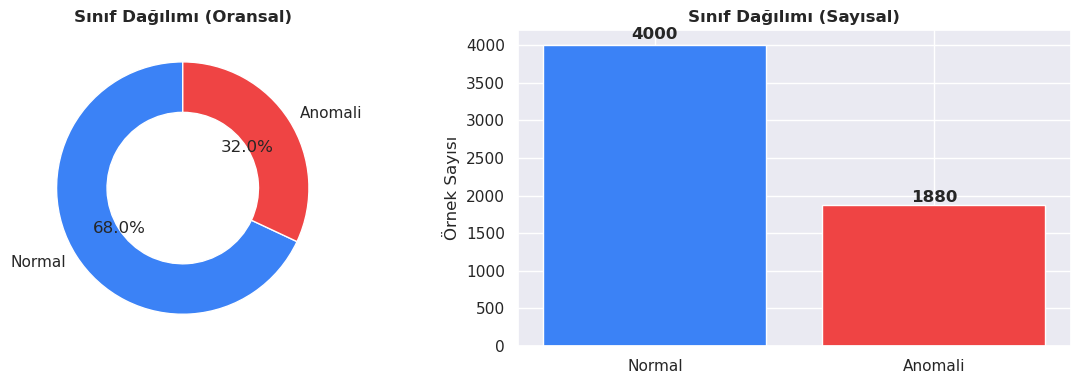

In [29]:
# Ham veri (raw_df) üzerindeki 'Normal' ve 'Anomali' sınıflarının dağılımını pasta ve bar grafik olarak hazırlıyoruz.
plot_class_distribution_combined(raw_df)

# Hazırlanan bu görseli ekrana basıyoruz.
plt.show()

### 2. Hastalık Kategorileri Dağılımı

**Amaç:** Hedef değişken olan anomalinin dışında, veri setindeki farklı hastalık veya hücre kategorilerinin (disease category) alt kırılımlarını anlamaktır.

**Bilimsel Katkısı:** Verideki anormalliklerin hangi spesifik patolojilerden kaynaklandığını görerek modelin genellenebilirliğini (generalization) yorumlamamızı sağlar. Belirli bir hastalık kategorisinin baskın olması durumunda, modelin o alt tipe aşırı uyum (overfitting) sağlayıp sağlamayacağını önceden sezebiliriz.

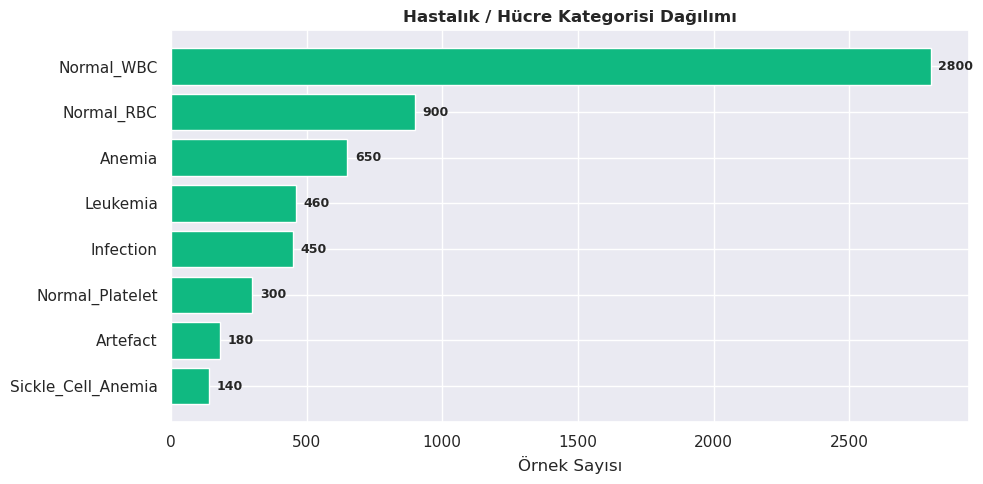

In [30]:
# Ham verideki (raw_df) hastalık ve hücre kategorilerinin dağılımını yatay bar grafiği olarak hazırlıyoruz. 
plot_disease_category_distribution(raw_df)

# Çizilen bu grafiği ekrana basıyoruz.
plt.show()

### 3. Korelasyon Isı Haritası (Correlation Heatmap)

**Amaç:** Sayısal değişkenler (özellikler) arasındaki doğrusal veya monotonik ilişkilerin yönünü ve şiddetini ölçmektir.

**Bilimsel Katkısı:** Değişkenler arası çoklu doğrusal bağlantı (multicollinearity) problemini tespit etmemizi sağlar. Birbirleriyle çok yüksek korelasyona sahip olan bağımsız değişkenler, özellikle doğrusal (linear) modellerde katsayıların (weights) güvenilirliğini azaltır ve varyans enflasyonuna (VIF) neden olur. Gerekirse yüksek korelasyonlu değişkenlerin elimine edilmesi için bize rehberlik eder.

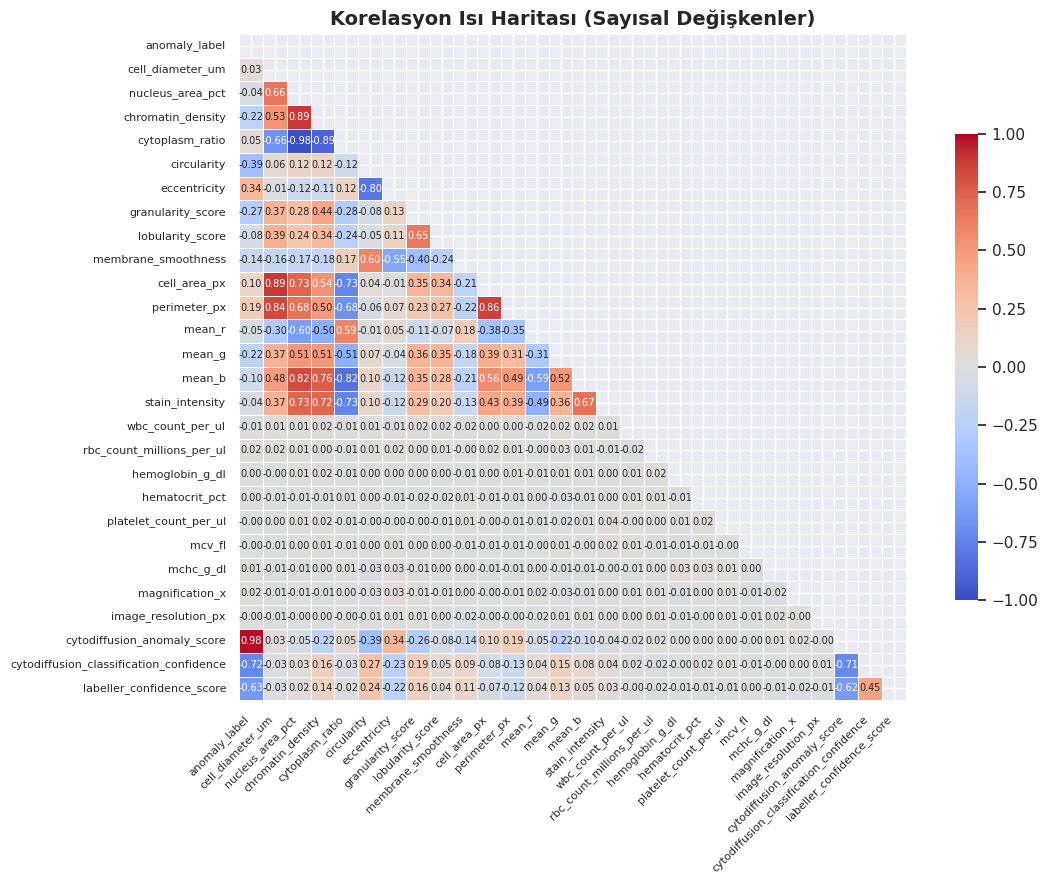

In [31]:
# Sayısal özelliklerin birbirleriyle ne kadar bağlantılı olduğunu (korelasyon) görmek için ısı haritasını çiziyoruz.
# (Hangi değişkenler birbiriyle çok benzer hareket ediyor, yani 'multicollinearity' var mı diye bakmak için şart)
plot_correlation_heatmap(raw_df)

# Çizilen ısı haritasını ekrana basıyoruz.
plt.show()

### 4. Özellik Dağılımları (KDE & Boxplot)

**Amaç:** Model için en ayırt edici olan özellikleri bularak (Cohen's d veya istatistiksel testlerle) bu özelliklerin Normal ve Anomali sınıflarındaki dağılımlarını Kernel Density Estimation (KDE) ve Boxplot ile görselleştirmektir.

**Bilimsel Katkısı:** Boxplot grafikleri, değişkenlerin varyansını ve medyan kaymalarını açıkça gösterirken olası aykırı değerleri (outliers) ortaya çıkarır. KDE ise dağılım formunu pürüzsüz bir yoğunluk eğrisi olarak yansıtarak, iki sınıfın ayrılabilirliğini (separability) görsel olarak ispatlar. Eğer bu özelliklerde sınıflar net bir şekilde ayrışıyorsa, makine öğrenmesi modelinin yüksek bir f1-skoru elde etmesi matematiksel olarak beklenir.

KDE ve Boxplot için Seçilen En Önemli Özellikler: ['circularity', 'eccentricity', 'granularity_score', 'chromatin_density']


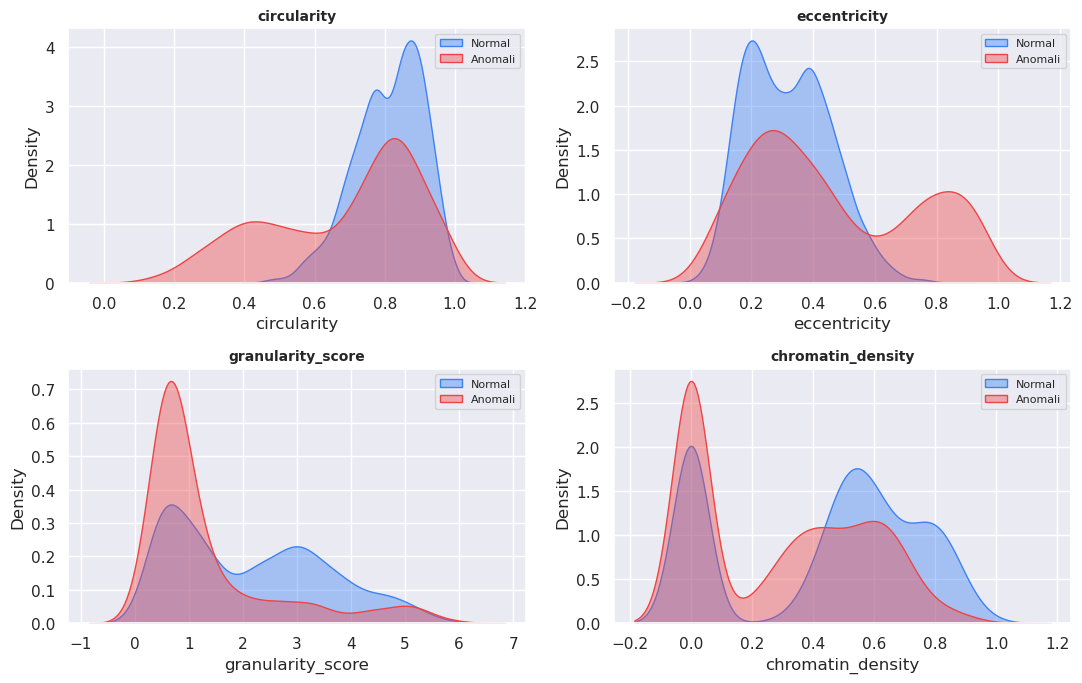

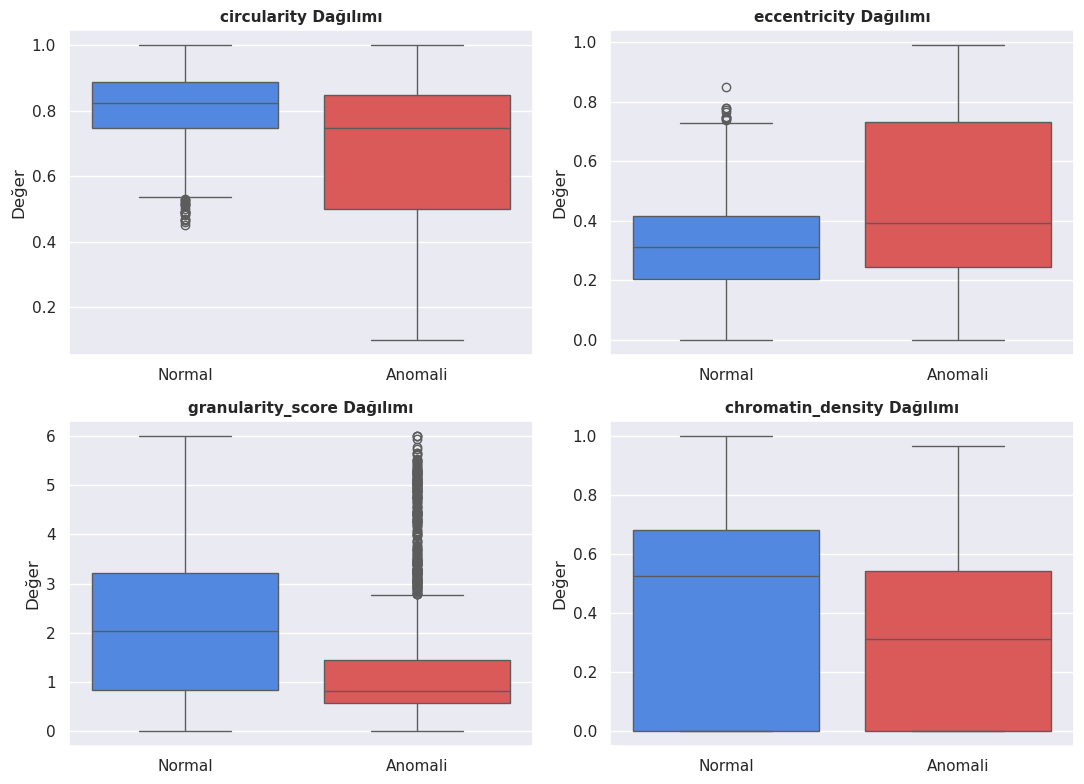

In [32]:
# Sınıfları (Normal vs Anomali) birbirinden en net şekilde ayıran (Cohen's d skoruna göre) en iyi 4 özelliği seçiyoruz.
top_features = get_top_features(df_clean, top_n=4)
print(f'KDE ve Boxplot için Seçilen En Önemli Özellikler: {top_features}')

# Seçtiğimiz bu en önemli 4 özelliğin yoğunluk (KDE) dağılımlarını üst üste çizdiriyoruz.
# (Anomali ve normal veriler birbirinden ne kadar ayrışmış ya da ne kadar iç içe geçmiş onu görmek için)
plot_kde_grid(df_clean, top_features)
plt.show()

# Aynı 4 özellik için bir de kutu grafiği (boxplot) çizdiriyoruz ki veri dağılımını ve aykırı değerleri (outliers) net görelim.
plot_boxplot_grid(df_clean, top_features)
plt.show()

### 4. Modellerin Tanımlanması ve Eğitimi

Bu projede üç farklı **ağaç tabanlı (tree-based) ensemble** model kullanılmıştır. Ağaç tabanlı modellerin tercih edilme nedenleri şunlardır:

| Avantaj | Açıklama |
|---|---|
| **Eksik veriye dayanıklılık** | XGBoost ve LightGBM, eksik değerleri doğal olarak yönetebilir |
| **Özellik ölçeklendirme gerektirmez** | Ağaç yapısı gereği, ölçeklendirmeden bağımsız çalışır (ancak pipeline tutarlılığı için yine de uygulanmıştır) |
| **Yüksek performans** | Tablo verilerinde (tabular data) derin öğrenme modellerini bile geride bırakan performans |
| **Aşırı öğrenme (overfitting) kontrolü** | Regularizasyon hiperparametreleri ile ezberleme riski minimize edilir |

---

#### 🔹 Neden Bu Üç Model?

**1. XGBoost (Extreme Gradient Boosting):**
Gradient boosting ailesinin en popüler üyesidir. Sıralı (sequential) olarak zayıf ağaçlar eğitir ve her yeni ağaç, önceki ağaçların **hatalarını düzeltmeye** odaklanır. L1/L2 regularizasyon desteği sayesinde overfitting'e karşı dirençlidir.

**2. LightGBM (Light Gradient Boosting Machine):**
Microsoft tarafından geliştirilen LightGBM, XGBoost'a kıyasla **çok daha hızlı** eğitim sunar. Leaf-wise (yaprak tabanlı) ağaç büyütme stratejisi kullanır; bu, level-wise (seviye tabanlı) stratejiye göre daha düşük kayıpla daha derin ağaçlar üretir.

**3. Random Forest:**
Bagging (Bootstrap Aggregating) yöntemiyle **paralel olarak** birbirinden bağımsız ağaçlar eğitir ve sonuçları çoğunluk oyuyla birleştirir. Boosting modellerine kıyasla daha az hassas hiperparametre ayarı gerektirir ve doğal olarak overfitting'e dirençlidir.


#### 🔹 Hiperparametre Seçimlerinin Gerekçeleri

| Hiperparametre | Değer | Gerekçe |
|---|---|---|
| `n_estimators=300` | Tüm modeller | 300 ağaç, bias-variance dengesini sağlayan optimal bir değerdir. Çok düşük değerler underfitting, çok yüksek değerler ise overfitting riskini artırır |
| `max_depth=6` (XGBoost) | XGBoost | Ağaç derinliğini sınırlayarak aşırı karmaşık kuralların öğrenilmesini (overfitting) engeller. 6, pratikte yaygın kullanılan dengeli bir değerdir |
| `max_depth=-1` (LightGBM) | LightGBM | Derinlik sınırı yoktur; LightGBM leaf-wise büyüdüğü için derinlik yerine `num_leaves` ile kontrol edilir |
| `learning_rate=0.1` | XGBoost, LightGBM | Her ağacın katkısını ölçekler. Düşük değer → daha yavaş ama daha stabil öğrenme. 0.1, hız ve performans arasında iyi bir denge sağlar |
| `subsample=0.8` | XGBoost, LightGBM | Her ağaç için verinin %80'i rastgele seçilir. Bu, Stochastic Gradient Boosting tekniğidir ve overfitting'i azaltır |
| `colsample_bytree=0.8` | XGBoost, LightGBM | Her ağaç için özelliklerin %80'i rastgele seçilir. Özellik çeşitliliğini artırarak modelin genelleştirme yeteneğini güçlendirir |
| `min_samples_split=5` | Random Forest | Bir düğümün bölünmesi için en az 5 örnek gerektirir; çok küçük yaprakların oluşmasını engeller |
| `min_samples_leaf=2` | Random Forest | Her yaprak düğümünde en az 2 örnek bulunmasını zorunlu kılar; overfitting'e karşı ek bir güvencedir |
| `eval_metric="logloss"` | XGBoost | Logloss (binary cross-entropy), ikili sınıflandırma için standart kayıp fonksiyonudur; olasılık tahminlerinin kalitesini ölçer |


#### 🔹 5-Fold Stratified Cross Validation

Modelin gerçek performansını güvenilir şekilde ölçmek için **5-Fold Stratified Cross Validation** uygulanmıştır.

**Neden Cross Validation?**
- Tek bir train/test bölmesi, verinin rastgele dağılımına **aşırı bağımlıdır**; farklı bölmelerde farklı sonuçlar üretir.
- CV, veriyi 5 eşit parçaya (fold) böler ve her seferinde 1 parçayı test, 4 parçayı eğitim olarak kullanır. **5 farklı değerlendirmenin ortalaması** alınarak daha güvenilir bir performans tahmini elde edilir.

**Neden Stratified?**
- `StratifiedKFold`, her fold'da hedef değişkenin (`anomaly_label`) **oransal dağılımını korur**.
- Bu, sınıf dengesizliği olan veri setlerinde (anomali oranı %50'den farklıysa) kritik öneme sahiptir. Aksi halde bazı fold'larda anomali örneği hiç bulunmayabilir.

**Neden F1-Score?**
- `scoring="f1"` parametresi ile CV skoru hesaplanır.
- Accuracy (doğruluk) sınıf dengesizliğinde yanıltıcı olabilir (tüm örnekleri "Normal" tahmin ederek %90+ accuracy elde edilebilir).
- **F1-Score**, Precision ve Recall'ın harmonik ortalamasıdır ve hem yanlış alarm (FP) hem de kaçırılan vaka (FN) maliyetini dengeler.


In [33]:
# Hangi modeli istersek (XGBoost, LightGBM veya Random Forest) ona uygun hiperparametrelerle modeli kurup döndüren fonksiyon.
def build_model(name: str, random_state: int = 42):
    if name == "XGBoost":
        return XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=random_state,
            verbosity=0, nthread=1,
        )
    if name == "LightGBM":
        return LGBMClassifier(
            n_estimators=300, max_depth=-1, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=random_state, verbose=-1, n_jobs=1,
        )
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=300, min_samples_split=5, min_samples_leaf=2,
            random_state=random_state, n_jobs=-1,
        )
    raise ValueError(f"Bilinmeyen model: {name}")

# Modeli çapraz doğrulama (Cross-Validation) ile sağlamasını yaparak eğiten ana fonksiyonumuz.
def train_with_cv(model, X_train, y_train, X_test, n_folds: int = 5,
                  random_state: int = 42):
    """5-fold StratifiedKFold CV + final fit + test tahmini."""
    
    # Veriyi 5 parçaya bölüp her defasında farklı bir parçayla test ederek (CV) modelin genelleme yeteneğini ölçüyoruz.
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                scoring="f1", n_jobs=1)
    
    # CV bittikten sonra modeli elimizdeki tüm eğitim verisiyle baştan son bir kez eğitiyoruz (fit).
    model.fit(X_train, y_train)
    
    # Test setindeki tahminleri (0 veya 1) ve olasılıkları (predict_proba) alıyoruz. ROC ve PR eğrileri için olasılıklar şart.
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    return {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "cv_scores": cv_scores,
        "cv_mean": float(cv_scores.mean()),
        "cv_std": float(cv_scores.std()),
    }

train_results = {}

# Listemizdeki tüm modelleri sırayla dönüp eğitiyor ve sonuçları bir sözlükte (dictionary) topluyoruz.
for name in MODEL_NAMES:
    print(f"Eğitiliyor: {name}...")
    
    # Önce modeli kur
    model = build_model(name, random_state=42)
    # Sonra CV ile eğit ve test et
    tr = train_with_cv(model, X_train, y_train, X_test, random_state=42)
    
    # Sonuçları kaydet ve ekrana F1 skorunu bas
    train_results[name] = tr
    print(f"  {name} 5-Fold CV F1 Ortalaması: {tr['cv_mean']:.4f}")

Eğitiliyor: XGBoost...
  XGBoost 5-Fold CV F1 Ortalaması: 0.9478
Eğitiliyor: LightGBM...
  LightGBM 5-Fold CV F1 Ortalaması: 0.9542
Eğitiliyor: Random Forest...
  Random Forest 5-Fold CV F1 Ortalaması: 0.9214


### 5. Model Değerlendirmesi ve Performans Karşılaştırma

Eğitilen modeller, hiç görmedikleri test verisi üzerinde değerlendirilir. Sınıflandırma başarısını ölçmek için Confusion Matrix (Karmaşıklık Matrisi), ROC ve Precision-Recall eğrileri çizdirilir.


In [34]:
# Modelin karnesini çıkaran ana fonksiyon.
# Özellikle dengesiz veri setlerinde Accuracy (doğruluk) yanıltıcı olabileceği için
# F1, MCC (Matthews Correlation Coefficient) ve Kappa gibi daha güvenilir ve sert metrikleri kullanıyoruz.
def evaluate(y_true, y_pred, y_proba=None, cv_mean=None, cv_std=None) -> dict:
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "confusion_mat": confusion_matrix(y_true, y_pred),
        "classification_rep": classification_report(
            y_true, y_pred, target_names=["Normal", "Anomali"]
        ),
        "cv_mean": cv_mean, "cv_std": cv_std,
    }
    # Model eğer tahmin olasılığı (probability) veriyorsa, ROC ve PR eğrileri için alan (AUC) hesaplıyoruz
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        out["roc_auc"] = auc(fpr, tpr)
        out["pr_auc"] = average_precision_score(y_true, y_proba)
    return out

# Modellerin sonuçlarını alıp, sunumluk janjanlı bir tabloya (DataFrame) çeviriyoruz.
def comparison_table(eval_results: dict) -> pd.DataFrame:
    rows = []
    for name, r in eval_results.items():
        rows.append({
            "Model": name,
            "Accuracy": r["accuracy"], "Bal. Acc.": r["balanced_accuracy"],
            "Precision": r["precision"], "Recall": r["recall"],
            "F1-Score": r["f1"], "MCC": r["mcc"], "Kappa": r["kappa"],
            "ROC-AUC": r.get("roc_auc"), "PR-AUC": r.get("pr_auc"),
            "CV Mean (F1)": r.get("cv_mean"),
        })
    # Tabloyu bizim için en kritik metrik olan F1-Score'a göre büyükten küçüğe sıralıyoruz
    return pd.DataFrame(rows).set_index("Model").sort_values("F1-Score", ascending=False)

eval_results = {}
roc_data = {}
pr_data = {}

# Eğittiğimiz tüm modelleri tek tek gezip test seti üzerindeki başarılarını ölçüyoruz
for name, tr in train_results.items():
    ev = evaluate(y_test, tr["y_pred"], tr["y_proba"], cv_mean=tr["cv_mean"], cv_std=tr["cv_std"])
    eval_results[name] = ev
    
    # İleride grafiklerini (ROC ve PR eğrileri) çizebilmek için verileri kenara kaydediyoruz
    if tr["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, tr["y_proba"])
        roc_data[name] = (fpr, tpr, auc(fpr, tpr))
        
        pr_arr, rc_arr, _ = precision_recall_curve(y_test, tr["y_proba"])
        pr_data[name] = (pr_arr, rc_arr, ev.get("pr_auc", 0))

# Tüm bu sonuçları toparlayıp karşılaştırma tablosunu oluşturuyoruz
comp_df = comparison_table(eval_results)
best_model_name = comp_df.index[0] # Tablo F1 skoruna göre sıralandığı için ilk sıradaki direkt en iyisi oluyor
print("Karşılaştırma Tablosu:")
display(comp_df)

print(f"\nEn İyi Model: {best_model_name}")

Karşılaştırma Tablosu:


,Accuracy,Bal. Acc.,Precision,Recall,F1-Score,MCC,Kappa,ROC-AUC,PR-AUC,CV Mean (F1)
Model,,,,,,,,,,
LightGBM,0.980442,0.972939,0.986226,0.952128,0.968877,0.954938,0.954624,0.997596,0.995564,0.954193
XGBoost,0.974490,0.965745,0.977901,0.941489,0.959350,0.941132,0.940772,0.997822,0.995834,0.947823
Random Forest,0.965136,0.947593,0.991202,0.898936,0.942817,0.920093,0.917827,0.996356,0.993827,0.921429



En İyi Model: LightGBM


### Karmaşıklık Matrisi (Confusion Matrix)

**Amaç:** Modelin sınıflandırma hatalarını False Positive (Tip I Hata) ve False Negative (Tip II Hata) olmak üzere granüler boyutta incelemektir.

**Bilimsel Katkısı:** Tıp ve sağlık gibi riskli alanlarda (örneğin kan hücresi anomalisi tespiti) False Negative'in (Hasta olan bir hücreye normal demek) maliyeti, False Positive'e kıyasla çok daha kritiktir. Matris üzerinden modelin hangi yönde hata yaptığını detaylandırarak, Precision (Kesinlik) veya Recall (Duyarlılık) trade-off'u hakkında nihai kararımızı destekliyoruz.

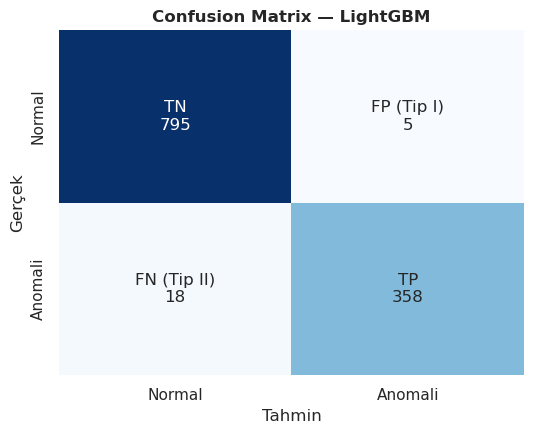

In [37]:
# Tüm modeller arasından birinci çıkan (en iyi F1 skoruna sahip) modelimizin hata matrisini (Confusion Matrix) çizdiriyoruz.
plot_confusion(y_test, train_results[best_model_name]['y_pred'], best_model_name)

# Hazırladığımız bu matrisi ekrana basıyoruz.
plt.show()

### ROC Eğrisi (Receiver Operating Characteristic)

**Amaç:** Modelin ayırt etme (discrimination) gücünü farklı karar eşiklerinde (thresholds) test etmektir.

**Bilimsel Katkısı:** ROC eğrisinin altında kalan alan (AUC - Area Under Curve), modelin rastgele bir anomaliyi normalden daha yüksek bir olasılıkla sıralama becerisini gösterir. AUC'nin 1'e yakın olması modelin sınıfları mükemmel bir şekilde ayırabildiğini kanıtlar; bu, literatürde modellerin birbirleriyle karşılaştırılması için kullanılan evrensel, eşikten bağımsız bir performans metriğidir.

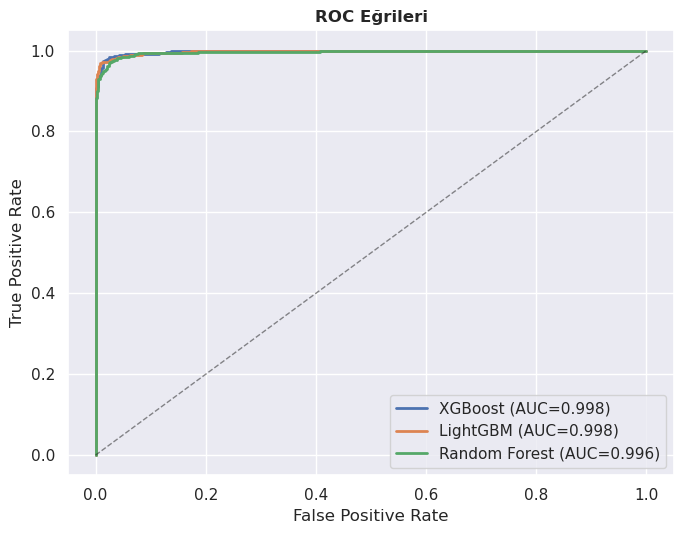

In [38]:
# Eğittiğimiz tüm modellerin ROC eğrilerini (ve AUC skorlarını) tek bir grafikte üst üste çizdiriyoruz.
plot_roc(roc_data)

# Hazırladığımız bu karşılaştırmalı grafiği ekrana basıyoruz.
plt.show()

### Precision-Recall (PR) Eğrisi

**Amaç:** Sınıf dengesizliği (class imbalance) durumunda, ROC eğrisinin aşırı iyimser (over-optimistic) sonuçlarını dengelemek için Precision ve Recall metriklerinin değişimini analiz etmektir.

**Bilimsel Katkısı:** Eğer pozitif (Anomali) sınıf azınlıktaysa, True Negative sayısındaki dramatik değişimler ROC'u yanıltabilir. PR Eğrisi doğrudan azınlık sınıftaki performansa odaklandığı için, tıbbi teşhis problemlerinde (minority detection) modelin sahada ne kadar güvenilir çalışacağını ölçmek için ROC'tan çok daha rasyonel bir vekil metrik (proxy) sunar.

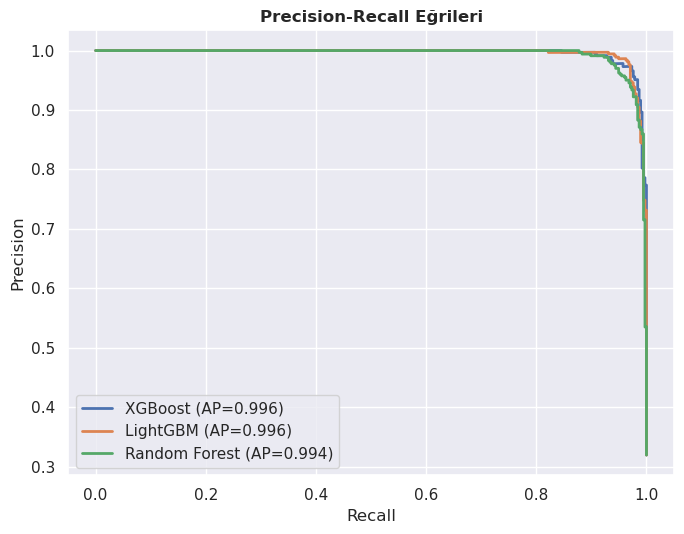

In [39]:
# Modellerin anomali (pozitif sınıf) yakalama becerisini gösteren Precision-Recall eğrilerini çiziyoruz.
plot_pr(pr_data)

# Hazırlanan grafiği ekrana basıyoruz.
plt.show()

**Değerlendirme ve Tıbbi Metrik Yorumu (False Negative Tehlikesi)**

Sağlık odaklı veri setlerinde "Doğruluk (Accuracy)" yanıltıcı bir metriktir. Asıl önemli olan, gerçekte hasta (anomali) olan bir hücrenin "sağlıklı" sanılarak gözden kaçırılmasıdır. Bu duruma **False Negative (Tip 2 Hata)** denir. False Negative oranının yüksek olması, tedavi edilmesi gereken bir hastanın eve gönderilmesi anlamına gelir ki bu hayati bir risktir.
Bu yüzden projede **Recall (Duyarlılık)** ve **F1-Score** metrikleri optimize edilmiştir. Confusion Matrix'te (Karmaşıklık Matrisi) sol alt köşedeki (FN) sayının olabildiğince sıfıra yakın olması en kritik başarı ölçütüdür.


### 6. Açıklanabilir Yapay Zeka (SHAP Analizi)

Makine öğrenmesi modelinin karar verme sürecini şeffaflaştırmak için SHAP kullanılır. Bu bölümde **Global Özellik Önemi** (modelin tüm veri setindeki genel davranışı) ve **Lokal Açıklama** (tek bir hücre için şelale grafiği ile verilen özel teşhis gerekçesi) incelenmektedir.


In [40]:
# Modelin kararlarını özellik bazında açıklamak için SHAP değerlerini hesaplayan fonksiyon.
# Ağaç tabanlı modellerde TreeExplainer, diğerlerinde ise KernelExplainer (daha yavaştır) kullanarak esneklik sağlar.
def compute_shap(model, X_sample: pd.DataFrame, X_background: pd.DataFrame = None):
    cls_name = type(model).__name__
    tree_models = ("XGBClassifier", "LGBMClassifier", "RandomForestClassifier")
    
    # Model tipine göre en verimli açıklayıcıyı seçiyoruz
    if cls_name in tree_models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    else:
        # KernelExplainer için referans veri seti (background) gerekir
        bg = X_background if X_background is not None else X_sample.head(50)
        explainer = shap.KernelExplainer(model.predict_proba, bg)
        shap_values = explainer.shap_values(X_sample, silent=True)

    # İkili sınıflandırmada sadece 'Anomali' (pozitif) sınıfın etkilerini filtreliyoruz
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    # Modelin ortalama tahmin değerini (base value) alıyoruz
    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = float(np.array(base).flatten()[-1])

    return {
        "shap_values": shap_values,
        "base_value": float(base),
        "X_sample": X_sample,
        "feature_names": list(X_sample.columns),
    }

# Özelliklerin model üzerindeki genel (global) etkisini ortalama mutlak SHAP değerine göre çizer.
def plot_shap_bar(result: dict, top_n: int = 15):
    mean_abs = np.abs(result["shap_values"]).mean(axis=0)
    s = pd.Series(mean_abs, index=result["feature_names"]).sort_values().tail(top_n)
    fig, ax = plt.subplots(figsize=(8, max(4, len(s) * 0.35)))
    ax.barh(s.index, s.values, color="#f59e0b")
    ax.set_xlabel("Ortalama |SHAP|")
    ax.set_title(f"Global Özellik Önemi — SHAP (Top {top_n})", weight="bold")
    plt.tight_layout()
    return fig

# Özelliklerin değerleri ile model tahmini arasındaki ilişkiyi (pozitif/negatif yönlü) özetleyen grafik.
def plot_shap_summary(result: dict, top_n: int = 15):
    plt.figure(figsize=(9, max(5, top_n * 0.4)))
    shap.summary_plot(result["shap_values"], result["X_sample"],
                      max_display=top_n, show=False)
    return plt.gcf()

# Tek bir örnek (satır) için modelin neden o kararı verdiğini açıklayan 'şelale' grafiği.
def plot_shap_waterfall(result: dict, idx: int, top_n: int = 12):
    shap_row = result["shap_values"][idx]
    x_row = result["X_sample"].iloc[idx]
    order = np.argsort(np.abs(shap_row))[-top_n:]
    feats = [result["feature_names"][i] for i in order]
    vals = shap_row[order]
    feat_vals = x_row.values[order]

    fig, ax = plt.subplots(figsize=(9, max(4, top_n * 0.45)))
    # Pozitif etki kırmızı (anomaliye iter), negatif etki mavi (normale çeker)
    colors = ["#ef4444" if v > 0 else "#3b82f6" for v in vals]
    ax.barh(range(len(feats)), vals, color=colors)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f"{f} = {v:.3f}" for f, v in zip(feats, feat_vals)],
                        fontsize=9)
    ax.axvline(0, color="black", lw=0.5)
    total = shap_row.sum()
    ax.set_title(
        f"Lokal Açıklama #{idx} — base={result['base_value']:+.3f}, "
        f"toplam SHAP={total:+.3f}", weight="bold"
    )
    ax.set_xlabel("SHAP değeri")
    plt.tight_layout()
    return fig

# Seçilen en iyi modeli ve test setinden bir örneklemi kullanarak hesaplamayı başlatıyoruz
best_model = train_results[best_model_name]["model"]
X_sample = X_test.head(200)

print("SHAP Değerleri Hesaplanıyor...")
shap_res = compute_shap(best_model, X_sample, X_train.head(100))

SHAP Değerleri Hesaplanıyor...


### SHAP (Açıklanabilir YZ) - Global Özellik Önemi (Beeswarm Plot)

**Amaç:** Modelin 'Black-Box' (kapalı kutu) doğasını kırıp, hangi veri özelliklerinin model tahminini evrensel (global) çapta en çok etkilediğini görmektir.

**Bilimsel Katkısı:** Ağaç tabanlı modellerin (örn. Random Forest, XGBoost) standart feature importance (Gini/Gain) değerleri sadece kural bölme sayısına dayanır ve yön belirtmez. SHAP, oyun teorisi (Shapley Values) kullanarak her bir özelliğin marjinal katkısını *pozitif* veya *negatif* yönlü ve matematiksel bir tutarlılıkla hesaplar. Böylece model kararlarının mantıklı (domain uzmanlığı ile örtüşen) paternler öğrenip öğrenmediği şeffaflaştırılır.


1. Global Özellik Önemi (Bar Chart)


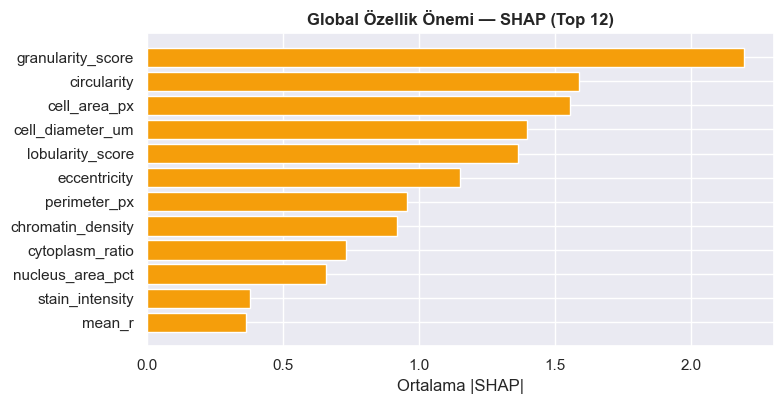


2. Global Özellik Önemi (Beeswarm Plot)


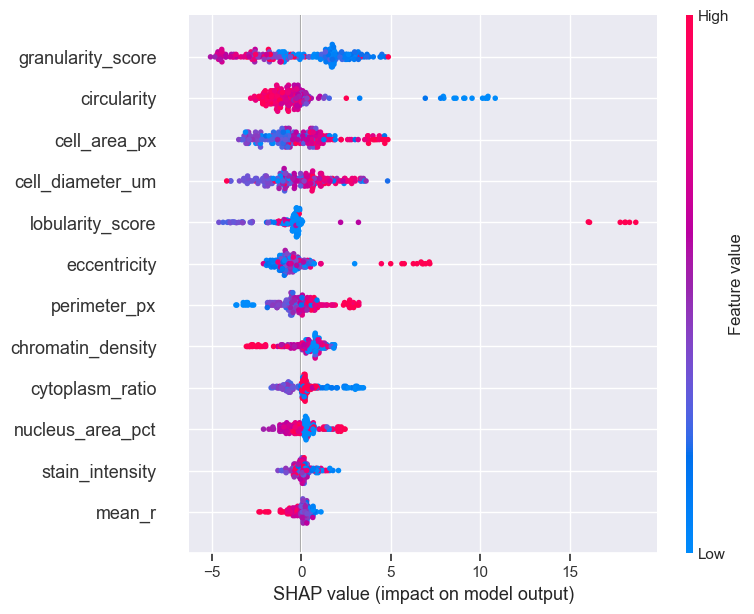

In [36]:
print('\n1. Global Özellik Önemi (Bar Chart)')
plot_shap_bar(shap_res, top_n=12)
plt.show()

print('\n2. Global Özellik Önemi (Beeswarm Plot)')
plot_shap_summary(shap_res, top_n=12)
plt.show()

### SHAP Waterfall Grafikleri - Örnek Vaka (Lokal) Analizleri

**Amaç:** Modelin global performansından ziyade, bireysel ve spesifik hücre örnekleri üzerinde neden 'Normal' veya 'Anomali' dediğini deşifre etmektir.

**Bilimsel Katkısı:** Gerçek dünyada bir hekimin 'Sistem bu hücreye neden anomali dedi?' sorusuna verilecek en somut cevaptır. Waterfall grafiği, base_value'dan (beklenen ortalama tahmin) başlayarak o anki hücrenin özellik değerlerinin modeli nasıl itip çektiğini gösterir. Doğru pozitif (TP), doğru negatif (TN) ve hatalı kararları (FP/FN) detaylı analiz ederek sistemin kör noktalarını ve güvenilirliğini tespit etmiş oluruz.


3. Örnek Vaka Analizleri (Lokal Açıklama - Waterfall Plots)

--- Vaka 1: Başarılı Anomali Tespiti (True Positive) ---
Gerçek Sınıf: Anomali | Modelin Tahmini: Anomali


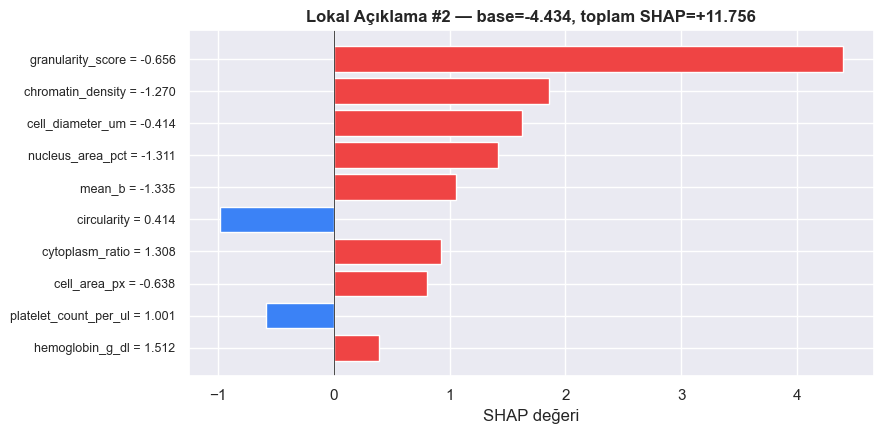


--- Vaka 2: Başarılı Normal Hücre Tespiti (True Negative) ---
Gerçek Sınıf: Normal | Modelin Tahmini: Normal


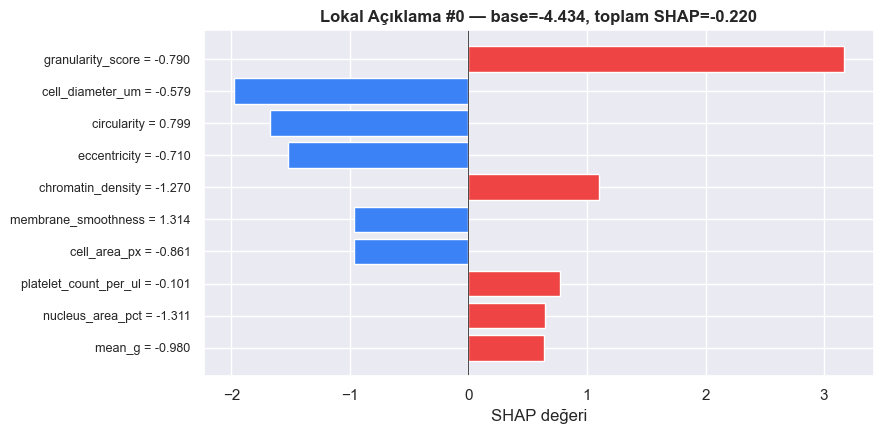


--- Vaka 3: Model Yanılgısı (Hata Analizi - FP/FN) ---
Gerçek Sınıf: Anomali | Modelin Tahmini: Normal


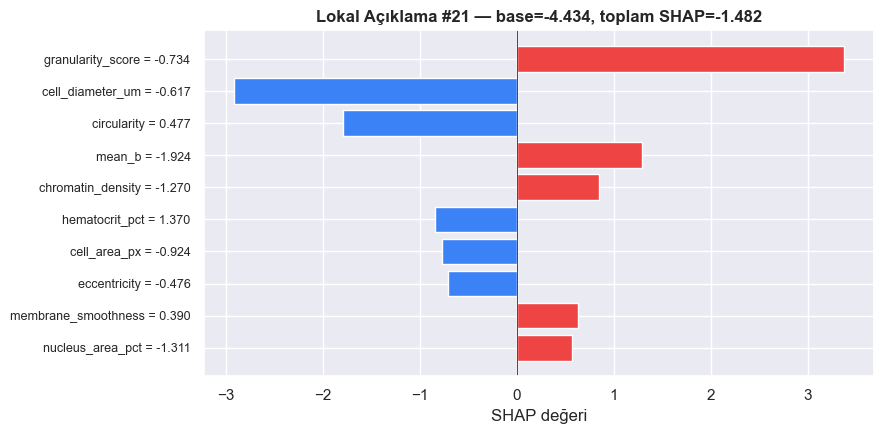

In [37]:
print('\n3. Örnek Vaka Analizleri (Lokal Açıklama - Waterfall Plots)')

y_arr = y_test.reset_index(drop=True)
preds = best_model.predict(X_sample)

tp_idx, tn_idx, err_idx = None, None, None
for i in range(len(X_sample)):
    actual = int(y_arr.iloc[i])
    pred = int(preds[i])
    if actual == 1 and pred == 1 and tp_idx is None: tp_idx = i
    elif actual == 0 and pred == 0 and tn_idx is None: tn_idx = i
    elif actual != pred and err_idx is None: err_idx = i
    if tp_idx is not None and tn_idx is not None and err_idx is not None: break

cases = [(tp_idx, 'Vaka 1: Başarılı Anomali Tespiti (True Positive)'),
         (tn_idx, 'Vaka 2: Başarılı Normal Hücre Tespiti (True Negative)'),
         (err_idx, 'Vaka 3: Model Yanılgısı (Hata Analizi - FP/FN)')]

for idx, title in cases:
    if idx is not None:
        print(f'\n--- {title} ---')
        actual = int(y_arr.iloc[idx])
        pred = int(preds[idx])
        actual_label = 'Anomali' if actual == 1 else 'Normal'
        pred_label = 'Anomali' if pred == 1 else 'Normal'
        print(f'Gerçek Sınıf: {actual_label} | Modelin Tahmini: {pred_label}')
        plot_shap_waterfall(shap_res, idx, top_n=10)
        plt.show()


**SHAP Metrikleri Yorumu**

*   **Global Özellik Önemi (Beeswarm Grafiği):** Bu grafik, modelin genel kanısında hangi özelliklerin en baskın rol oynadığını gösterir. Kırmızı noktalar o özelliğin yüksek değerini, mavi noktalar düşük değerini temsil eder. Örneğin bir noktanın sağa (pozitif SHAP değerine) gitmesi, o özelliğin modeli "Anomali" kararına ittiği anlamına gelir.
*   **Lokal Açıklama (Waterfall - Şelale Grafiği):** Bu grafik sadece belirli bir hasta (veya hücre) için çalışır. Taban değerden (base value) başlayarak, o spesifik hücrenin sahip olduğu kan değerlerinin (örneğin hücre çapının geniş olması) sonucu nasıl yukarı (anomali) veya aşağı (normal) çektiğini adım adım gösterir. Tıbbi bir teşhisin sağlamasını yapmak için doktorlara sunulacak en kritik analizdir.
